# Game of Thrones: Character Social Fingerprints Through Dialogue Analysis

**Course:** DATA200 Midterm Project  
**Date:** March 2, 2026


## Research Question

**"How do different Houses address individual characters in Game of Thrones, and what does this reveal about each character's 'social fingerprint' within the political landscape?"**

This project I will investigate the "political fingerprint" of Westeros by analyzing how characters are spoken to by different Houses. I use computational linguistics to map the social hierarchy and reputation dynamics of the Seven Kingdoms.

## Contents Overview

This jupyter notebook contains a complete computational linguistics analysis of Game of Thrones dialogue data. The analysis follows a structured pipeline from data cleaning through statistical modeling.
1. **Setup and Data Loading** - Import libraries (pandas, numpy, matplotlib, networkx, VADER)
2. **Data Cleaning and Preprocessing** - Use regex to clean character names, remove generic characters, filter to top 20 characters 
3. **House Allegiances** - Manually assign 20 main characters to 6 major houses (Stark, Lannister, Targaryen, Greyjoy, Baratheon, Tyrell)
4. **Sentiment Analysis** - Apply VADER to measure emotional tone of each dialogue line (positive, negative, neutral, compound scores)
5. **House-Specific Keywords** - Extract house vocabulary patterns using regex (locations, values, symbols, titles)
6. **Social Dynamics Patterns** - Identify linguistic markers of loyalty, power, respect, and addressing style
7. **Reputation Metrics** - Calculate incoming sentiment, respect, and power directed at each character
8. **Character-Level Aggregation** - Aggregate line-level features to character level using groupby operations
9. **Network Graph** - Visualize top 10 character interactions with NetworkX (nodes sized by PageRank centrality)
10. **Reputation Matrix** - Create weighted heatmap showing how different houses address specific characters 
11. **Statistical Modeling** - Test linear regression: does PageRank predict reputation? 
12. **Conclusion** - Summarize findings, limitations, and future modeling extensions



## Setup and Data Loading

Import necessary libraries and load the Game of Thrones dialogue dataset from Kaggle.

In [1]:
# import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import re
from collections import defaultdict, Counter

# import VADER for sentiment analysis
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

In [2]:
# load the Game of Thrones dialogue dataset from Kaggle
import kagglehub
import os

path = kagglehub.dataset_download("albenft/game-of-thrones-script-all-seasons")
csv_files = [f for f in os.listdir(path) if f.endswith('.csv')]

# load the main dataset
csv_path = os.path.join(path, csv_files[0])
df_raw = pd.read_csv(csv_path)

print(f"Dataset shape: {df_raw.shape}")
df_raw.head(6)


Dataset shape: (23911, 6)


,Release Date,Season,Episode,Episode Title,Name,Sentence
0,2011-04-17,Season 1,Episode 1,Winter is Coming,waymar royce,What do you expect? They're savages. One lot s...
1,2011-04-17,Season 1,Episode 1,Winter is Coming,will,I've never seen wildlings do a thing like this...
2,2011-04-17,Season 1,Episode 1,Winter is Coming,waymar royce,How close did you get?
3,2011-04-17,Season 1,Episode 1,Winter is Coming,will,Close as any man would.
4,2011-04-17,Season 1,Episode 1,Winter is Coming,gared,We should head back to the wall.
5,2011-04-17,Season 1,Episode 1,Winter is Coming,royce,Do the dead frighten you?


## Data Cleaning and Preprocessing
Raw dialogue data contains noise that interferes with analysis. I clean character names using **Regex** to ensure consistent matching when detecting interactions:
1. **Remove surnames** - "Jon Snow" -> "Jon" (characters address each other by first name)
2. **Strip script directions** - Remove `(CONT'D)`, `(V.O.)`, and title prefixes like "Lord" or "Ser"
3. **Filter to top 20 characters** - Focus on characters with sufficient dialogue for reliable patterns
4. **Exclude generic names** - Remove "Guard", "Soldier", etc. (non-specific characters)

In [3]:
# this is a list of generic names that I assume to exclude
generic_names = [
    'Man', 'Woman', 'Guard', 'Soldier', 'Boy', 'Girl', 'Child',
    'Servant', 'Maester', 'Septa', 'Septon', 'Merchant', 'Farmer',
    'Prostitute', 'Prisoner', 'Peasant', 'Villager', 'Townsperson',
    'Knight', 'Lord', 'Lady', 'Brother', 'Sister', 'Mother', 'Father',
    'Old Man', 'Old Woman', 'Young Man', 'Young Woman', 'Voice'
]

def clean_character_name(name):
    name = str(name)
    # remove parentheses and their contents: (CONT'D), (V.O.), (O.S.)
    name = re.sub(r'\([^)]*\)', '', name)
    # remove common titles
    name = re.sub(r'\b(Lord|Lady|Ser|King|Queen|Maester|Grand Maester)\s+', '', name, flags=re.IGNORECASE)
    # strip whitespace and capitalize properly
    name_clean = name.strip().title()
    # check full name against multi-word generics before splitting
    if name_clean in generic_names:
        return None
    # remove surname
    name_parts = name_clean.split()
    if len(name_parts) > 0:
        first_name = name_parts[0]
    else:
        return None
    # filter out single-word generic names and very short names
    if first_name in generic_names or len(first_name) < 2:
        return None
    return first_name

# apply name cleaning
df = df_raw.copy()
df['Character'] = df['Name'].apply(clean_character_name)

print(f"Original unique names: {df_raw['Name'].nunique()}")
print(f"Number of lines spoken by generic characters: {df['Character'].isnull().sum()}")

# remove rows with null characters and filter to top 20 by dialogue count
df = df[df['Character'].notna()].copy()

# count dialogue lines per character
character_counts = df['Character'].value_counts()

print(f"Total unique characters (after removing nulls): {len(character_counts)}")
print(f"\nTop 5 characters by dialogue count:")
print(character_counts.head())

# filter to top 20 characters
top_20_characters = character_counts.head(20).index.tolist()
df_top20 = df[df['Character'].isin(top_20_characters)].copy()

print(f"Retained {len(df_top20)/len(df)*100:.1f}% of cleaned data ({len(df_top20)} lines)")

Original unique names: 564
Number of lines spoken by generic characters: 824
Total unique characters (after removing nulls): 429

Top 5 characters by dialogue count:
Character
Tyrion      1760
Jon         1133
Daenerys    1048
Cersei      1005
Jaime        945
Name: count, dtype: int64
Retained 55.6% of cleaned data (12839 lines)


**Note:** By removing dialogue lines spoken by generic characters, I retained 55.6% of the original dataset. Focusing on named characters allows us to concentrate on meaningful patterns in speech and social interactions, though this means the analysis excludes broader social context from generic interactions.


## Defining House Allegiances

I manually assign house allegiances based on **birth house**, not temporary political positions.

**Exceptional cases:**
- Jon is STARK (raised as Stark, culturally Stark)
- Theon is GREYJOY (his birth house, despite being raised by Starks)
- Varys is UNKNOWN (no official noble house affiliation)

In [4]:
# define house allegiances for each character
house_allegiances = {
    'Tyrion': 'Lannister',
    'Jon': 'Stark',  # raised as Stark, culturally Stark
    'Daenerys': 'Targaryen',
    'Cersei': 'Lannister',
    'Jaime': 'Lannister',
    'Sansa': 'Stark',
    'Arya': 'Stark',
    'Sam': 'Tarly',
    'Davos': 'Seaworth',
    'Petyr': 'Baelish',
    'Theon': 'Greyjoy',
    'Jorah': 'Mormont',
    'Bran': 'Stark',
    'Bronn': 'Lannister',  # sellsword, primarily served Lannisters
    'Varys': 'Unknown',
    'Tywin': 'Lannister',
    'Brienne': 'Tarth',
    'Sandor': 'Lannister',  # house Clegane, bannermen of Lannisters
    'Eddard': 'Stark',
    'Robb': 'Stark'
}

# map house allegiances to characters
df_top20['House'] = df_top20['Character'].map(house_allegiances)

# create House_Category column: major houses keep their name, minor houses become "Other Notable"
major_houses = ['Stark', 'Lannister', 'Targaryen', 'Tyrell', 'Baratheon', 'Greyjoy']
df_top20['House_Category'] = df_top20['House'].apply(
    lambda x: x if x in major_houses else 'Other Notable'
)

# not every House in the show has enough dialogue for a analysis, so I filter out the noise of smaller houses
# filter to major houses with sufficient dialogue for analysis
df_major = df_top20[df_top20['House'].isin(major_houses)].copy()

print(f"\nHouse distribution (top 4):")
print(df_major['House'].value_counts().head(4))
print(f"\nPercentage of data in major houses: {len(df_major)/len(df_top20)*100:.1f}%")


House distribution (top 4):
House
Lannister    4852
Stark        3757
Targaryen    1048
Greyjoy       455
Name: count, dtype: int64

Percentage of data in major houses: 78.8%


**Note:** Houses Lannister and Stark dominate the dataset with over 8000 combined dialogue lines, providing a robust baseline for linguistic analysis. Major houses represent 78.8% of the filtered data, ensuring comprehensive coverage of the primary political dynamics.



## Internal Sentiment (VADER)

I use VADER sentiment analysis to measure the emotional tone of each dialogue line. VADER provides 4 scores:

- **Positive**: Proportion of positive emotion (0-1)
- **Negative**: Proportion of negative emotion (0-1)
- **Neutral**: Proportion of neutral emotion (0-1)
- **Compound**: Overall sentiment score (-1 to +1, normalized)

This captures how characters express themselves, allowing us to identify if different houses have distinct emotional communication styles.

In [5]:
# initialize VADER sentiment analyzer
sia = SentimentIntensityAnalyzer()

# calculate VADER sentiment scores for a piece of text.
def get_sentiment_scores(text):
    if pd.isna(text) or text == "":
        return {'pos': 0, 'neg': 0, 'neu': 1, 'compound': 0}
    return sia.polarity_scores(str(text))

# apply sentiment analysis to each line
sentiment_scores = df_top20['Sentence'].apply(get_sentiment_scores)

# extract individual sentiment components
df_top20['sentiment_positive'] = sentiment_scores.apply(lambda x: x['pos'])
df_top20['sentiment_negative'] = sentiment_scores.apply(lambda x: x['neg'])
df_top20['sentiment_neutral'] = sentiment_scores.apply(lambda x: x['neu'])
df_top20['sentiment_compound'] = sentiment_scores.apply(lambda x: x['compound'])

# filter to major houses after sentiment analysis
df_major = df_top20[df_top20['House'].isin(major_houses)].copy()

print(f"Sentiment scores calculated for {len(df_top20)} dialogue lines (all top 20 characters)")
print(f"Major houses dataset now has {len(df_major)} lines")
print(f"\nSentiment score ranges:")
print(f"  Positive:  {df_major['sentiment_positive'].min():.3f} to {df_major['sentiment_positive'].max():.3f}")
print(f"  Negative:  {df_major['sentiment_negative'].min():.3f} to {df_major['sentiment_negative'].max():.3f}")
print(f"  Neutral:   {df_major['sentiment_neutral'].min():.3f} to {df_major['sentiment_neutral'].max():.3f}")
print(f"  Compound:  {df_major['sentiment_compound'].min():.3f} to {df_major['sentiment_compound'].max():.3f}")

print(f"\nAverage sentiment by house (major houses):")
sentiment_by_house = df_major.groupby('House')[['sentiment_positive', 'sentiment_negative',
                                                  'sentiment_neutral', 'sentiment_compound']].mean()
sentiment_by_house.reset_index().round(3)

Sentiment scores calculated for 12839 dialogue lines (all top 20 characters)
Major houses dataset now has 10112 lines

Sentiment score ranges:
  Positive:  0.000 to 1.000
  Negative:  0.000 to 1.000
  Neutral:   0.000 to 1.000
  Compound:  -0.986 to 0.984

Average sentiment by house (major houses):


,House,sentiment_positive,sentiment_negative,sentiment_neutral,sentiment_compound
0,Greyjoy,0.094,0.103,0.803,-0.020
1,Lannister,0.113,0.094,0.793,0.016
2,Stark,0.100,0.084,0.816,0.004
3,Targaryen,0.106,0.078,0.816,0.038


**Key Findings:**

1. **House Greyjoy**: Only house with negative compound score (-0.020), reflecting confrontational communication aligned with their aggressive identity.

2. **House Stark**: Highest neutral score (0.816), indicating direct, instructional speech without emotional embellishment.

3. **House Targaryen**: Most positive sentiment (+0.038), driven by Daenerys's aspirational language about justice and freedom.



## House-Specific Keywords

Each Great House has distinctive vocabulary related to geography, values, and symbols. I use regex patterns to count mentions of house-specific terms to test whether characters naturally use vocabulary associated with their house allegiance.

In [6]:
# define house-specific regex patterns
house_patterns = {
    'Stark': {
        'locations': r'\b(winterfell|north|the north|wall|castle black)\b',
        'values': r'\b(honor|honour|duty|winter is coming|loyalty)\b',
        'symbols': r'\b(wolf|wolves|direwolf|direwolves)\b',
        'titles': r'\b(warden of the north|king in the north)\b'
    },
    'Lannister': {
        'locations': r'\b(casterly rock|lannisport|kings landing|king\'s landing)\b',
        'values': r'\b(gold|debt|debts|wealth|power|hear me roar)\b',
        'symbols': r'\b(lion|lions|crimson|golden)\b',
        'titles': r'\b(hand of the king|lord of casterly rock)\b'
    },
    'Targaryen': {
        'locations': r'\b(dragonstone|essos|mereen|meereen|valyria)\b',
        'values': r'\b(fire and blood|blood of the dragon|rightful|throne)\b',
        'symbols': r'\b(dragon|dragons|drogon|rhaegal|viserion|fire)\b',
        'titles': r'\b(khaleesi|mother of dragons|breaker of chains)\b'
    },
    'Greyjoy': {
        'locations': r'\b(iron islands|pyke|old wyk)\b',
        'values': r'\b(we do not sow|what is dead may never die|ironborn)\b',
        'symbols': r'\b(kraken|sea|iron price)\b'
    },
    'Baratheon': {
        'locations': r'\b(storms end|storm\'s end|dragonstone)\b',
        'values': r'\b(ours is the fury|fury|rightful king)\b',
        'symbols': r'\b(stag|crowned stag)\b'
    },
    'Tyrell': {
        'locations': r'\b(highgarden|the reach)\b',
        'values': r'\b(growing strong|roses)\b',
        'symbols': r'\b(rose|golden rose)\b'
    }
}

# count how many times house-specific keywords appear in text
def count_house_mentions(text, house_name):

    if pd.isna(text) or text == "":
        return 0

    text_lower = str(text).lower()
    total_count = 0

    if house_name in house_patterns:
        for pattern_type, pattern in house_patterns[house_name].items():
            matches = re.findall(pattern, text_lower)
            total_count += len(matches)

    return total_count

# count mentions for each house (on df_top20 so all characters have keyword counts)
for house in ['Stark', 'Lannister', 'Targaryen', 'Greyjoy', 'Baratheon', 'Tyrell']:
    col_name = f'{house}_mentions'
    df_top20[col_name] = df_top20['Sentence'].apply(lambda x: count_house_mentions(x, house))

# update df_major to include the new columns
df_major = df_top20[df_top20['House'].isin(major_houses)].copy()
mention_cols = [col for col in df_major.columns if col.endswith('_mentions')]
print(f"Created {len(mention_cols)} mention count features")

print(f"\nTotal mentions by house keyword category:")
for col in mention_cols:
    total = df_major[col].sum()
    print(f"  {col}: {total}")

print(f"\nAverage mentions per dialogue line by actual house:")
avg_mentions = df_major.groupby('House')[mention_cols].mean()
avg_mentions.reset_index().round(3)


Created 6 mention count features

Total mentions by house keyword category:
  Stark_mentions: 587
  Lannister_mentions: 327
  Targaryen_mentions: 366
  Greyjoy_mentions: 93
  Baratheon_mentions: 24
  Tyrell_mentions: 27

Average mentions per dialogue line by actual house:


,House,Stark_mentions,Lannister_mentions,Targaryen_mentions,Greyjoy_mentions,Baratheon_mentions,Tyrell_mentions
0,Greyjoy,0.086,0.026,0.004,0.086,0.000,0.000
1,Lannister,0.037,0.048,0.034,0.004,0.001,0.005
2,Stark,0.089,0.017,0.016,0.005,0.003,0.001
3,Targaryen,0.032,0.017,0.134,0.016,0.007,0.002


**Key Findings:**

1. **House Stark** serves as the primary linguistic anchor (587 mentions), frequently referenced even by non-Stark characters.  
2. **House Targaryen** has the highest self-reference rate (0.133), demonstrating linguistic self-reinforcement of their throne claim and cultural values.  

**Limitation**: The regex approach cannot distinguish between geographic references and House allegiances (e.g., 'the north' as direction vs. 'The North' as political entity).



## Social Dynamics Patterns

I create additional linguistic features to capture social interaction patterns:

1. **Loyalty patterns**: Phrases showing deference or service (`i serve`, `your grace`)
2. **Power dynamics**: Commands and assertions (`command`, `must`, `will do`)
3. **Respect markers**: Formal address and polite requests
4. **Address scope**: Individual vs. group address patterns


In [7]:
# define social dynamic patterns
social_patterns = {
    'loyalty': r'\b(i serve|my duty|loyal|swear|oath|pledge|your grace)\b',
    'power_command': r'\b(command|order|must|will do|shall|demand)\b',
    'power_declare': r'\b(i am|i will|i shall|i claim)\b',
    'respect_formal': r'\b(my (lord|lady|king|queen|grace)|your (grace|majesty|highness)|ser)\b',
    'respect_request': r'\b(please|kindly|may i|might i|could you|would you)\b',
    'group_address': r'\b(you all|everyone|all of you|lords and ladies)\b',
    'individual_address': r'\b(you and i|just you|you alone|you must|you will)\b'
}

# count occurrences of a regex pattern in text
def count_pattern(text, pattern):
    if pd.isna(text) or text == "":
        return 0
    text_lower = str(text).lower()
    return len(re.findall(pattern, text_lower))

# apply social pattern counts (on df_top20 so all characters have pattern features)
for pattern_name, pattern in social_patterns.items():
    df_top20[f'pattern_{pattern_name}'] = df_top20['Sentence'].apply(
        lambda x: count_pattern(x, pattern)
    )

df_major = df_top20[df_top20['House'].isin(major_houses)].copy()

pattern_cols = [col for col in df_major.columns if col.startswith('pattern_')]

print("Total occurrences by pattern type:")
for col in pattern_cols:
    total = df_major[col].sum()
    pattern_name = col.replace('pattern_', '')
    print(f"  {pattern_name}: {total}")

print("\nAverage pattern usage by house:")
pattern_by_house = df_major.groupby('House')[pattern_cols].mean()
pattern_by_house.reset_index().round(3)

Total occurrences by pattern type:
  loyalty: 189
  power_command: 205
  power_declare: 264
  respect_formal: 404
  respect_request: 195
  group_address: 94
  individual_address: 131

Average pattern usage by house:


,House,pattern_loyalty,pattern_power_command,pattern_power_declare,pattern_respect_formal,pattern_respect_request,pattern_group_address,pattern_individual_address
0,Greyjoy,0.015,0.009,0.033,0.046,0.068,0.007,0.009
1,Lannister,0.017,0.026,0.024,0.038,0.016,0.009,0.016
2,Stark,0.023,0.011,0.017,0.044,0.018,0.010,0.005
3,Targaryen,0.011,0.032,0.068,0.031,0.016,0.010,0.027


**Key Findings:**

1. **Formal respect** is the most common social pattern (404 occurrences), while group addressing is the rarest (94 occurrences), suggesting intimate one-on-one dialogue dominates.
2. **Power command usage**: House Targaryen (0.032) and House Lannister (0.026) exhibit the highest frequency of command-based dialogue patterns.
3. **Power declarations**: Targaryen's pattern_power_declare (0.067) is highest, confirming Daenerys's assertive self-declarations ("I am...").
4. **Loyalty patterns**: House Stark leads (0.023), making their identity statistically visible through words like duty, oath, and pledge.  


**Limitation**: Text-only analysis cannot recognize vocal tone or context, potentially missing sarcasm or ironic speech. 



## External Reputation Metrics

I calculate how characters are addressed by others (external reputation) by analyzing:
- **Incoming sentiment**: Average sentiment in dialogue directed at each character
- **Incoming respect**: Frequency of formal respect markers used toward them
- **Incoming power**: Frequency of power/command language directed at them

In [8]:
# build interactions dictionary for network analysis
interactions = defaultdict(lambda: defaultdict(int))

reputation_data = []

for idx, row in df_major.iterrows():
    speaker = row['Character']
    dialogue = str(row['Sentence']).lower()
    sentiment = row['sentiment_compound']
    respect = row['pattern_respect_formal']
    power = row['pattern_power_command']

    # find who is being addressed in this dialogue
    for target_char in top_20_characters:
        if target_char != speaker:
            if re.search(r'\b' + re.escape(target_char.lower()) + r'\b', dialogue):
                reputation_data.append({
                    'target': target_char,
                    'incoming_sentiment': sentiment,
                    'incoming_respect': respect,
                    'incoming_power': power
                })
                # build interactions dictionary
                interactions[speaker][target_char] += 1

reputation_df = pd.DataFrame(reputation_data)

# check if we have data to process
if len(reputation_df) == 0:
    print("Warning: No reputation data found. Creating empty reputation features.")
    incoming_features = pd.DataFrame(columns=['Character', 'reputation_sentiment', 'reputation_respect',
                                               'reputation_power', 'interaction_count',
                                               'reputation_respect_rate', 'reputation_power_rate'])
else:
    # aggregate incoming metrics by target character
    incoming_features = reputation_df.groupby('target').agg({
        'incoming_sentiment': 'mean',
        'incoming_respect': 'sum',
        'incoming_power': 'sum'
    }).reset_index()
    incoming_features.columns = ['Character', 'reputation_sentiment', 'reputation_respect', 'reputation_power']

    # normalize by interaction count
    interaction_counts = reputation_df['target'].value_counts().to_dict()
    incoming_features['interaction_count'] = incoming_features['Character'].map(interaction_counts).fillna(1)

    # calculate rates
    incoming_features['reputation_respect_rate'] = (incoming_features['reputation_respect'] / incoming_features['interaction_count']).fillna(0)
    incoming_features['reputation_power_rate'] = (incoming_features['reputation_power'] / incoming_features['interaction_count']).fillna(0)

    # replace any infinity values with 0
    incoming_features['reputation_respect_rate'] = incoming_features['reputation_respect_rate'].replace([np.inf, -np.inf], 0)
    incoming_features['reputation_power_rate'] = incoming_features['reputation_power_rate'].replace([np.inf, -np.inf], 0)

print(f"\nReputation metrics calculated:")
print(f"  Total reputation data points: {len(reputation_df)}")
print(f"  Characters with reputation features: {len(incoming_features)}")

print(f"\nTop 6 characters by reputation sentiment:")
incoming_features[['Character', 'reputation_sentiment', 'reputation_respect_rate', 'reputation_power_rate']].head(6).round(3)



Reputation metrics calculated:
  Total reputation data points: 857
  Characters with reputation features: 20

Top 6 characters by reputation sentiment:


,Character,reputation_sentiment,reputation_respect_rate,reputation_power_rate
0,Arya,-0.011,0.000,0.024
1,Bran,-0.022,0.059,0.000
2,Brienne,0.028,0.130,0.087
3,Bronn,0.029,0.333,0.000
4,Cersei,-0.006,0.051,0.020
5,Daenerys,-0.005,0.018,0.036


**Key Findings:**
- Bronn leads the group with the highest Sentiment (0.029) and a massive Respect Rate (0.33). I guess because he refers himself or other characters address him as "Ser Bronn".
- Brienne has the highest Power Rate (0.087) and high Respect (0.13).
- Both Cersei & Daenerys show Negative Sentiment (-0.006 and -0.004) despite their high status.



## Character-Level Aggregation

I aggregate all line-level features to the character level using `groupby()`, creating a final dataset where each row represents one character.
- **Split**: Group data by Character and House
- **Apply**: Calculate mean sentiment, sum keyword counts
- **Combine**: Create normalized rates (counts per dialogue line)

In [9]:
# define aggregation functions
agg_functions = {
    'Sentence': 'count',
    'sentiment_positive': 'mean',
    'sentiment_negative': 'mean',
    'sentiment_neutral': 'mean',
    'sentiment_compound': 'mean',
}

# add house mention columns
mention_cols = [col for col in df_major.columns if col.endswith('_mentions')]
for col in mention_cols:
    agg_functions[col] = 'sum'

# add social pattern columns
pattern_cols = [col for col in df_major.columns if col.startswith('pattern_')]
for col in pattern_cols:
    agg_functions[col] = 'sum'

# perform groupby aggregation
char_features = df_major.groupby(['Character', 'House', 'House_Category']).agg(agg_functions).reset_index()
char_features.rename(columns={'Sentence': 'dialogue_count'}, inplace=True)

# normalize count-based features by dialogue count to get rates
count_features = mention_cols + pattern_cols
for col in count_features:
    char_features[f'{col}_rate'] = char_features[col] / char_features['dialogue_count']

# add network centrality features
G = nx.DiGraph()
for speaker, targets in interactions.items():
    for target, weight in targets.items():
        if G.has_edge(speaker, target):
            G[speaker][target]['weight'] += weight
        else:
            G.add_edge(speaker, target, weight=weight)

in_degree = dict(G.in_degree(weight='weight'))
out_degree = dict(G.out_degree(weight='weight'))
pagerank = nx.pagerank(G, weight='weight')

char_features['network_in_degree'] = char_features['Character'].map(in_degree).fillna(0)
char_features['network_out_degree'] = char_features['Character'].map(out_degree).fillna(0)
char_features['network_pagerank'] = char_features['Character'].map(pagerank).fillna(0)

# merge external reputation features
char_features = char_features.merge(incoming_features[['Character', 'reputation_sentiment',
                                                         'reputation_respect_rate', 'reputation_power_rate']],
                                     on='Character', how='left')
char_features.fillna(0, inplace=True)

print(f"\nCharacter-level features summary (first 6):")
char_features[['Character', 'House', 'dialogue_count', 'sentiment_compound',
                      'reputation_sentiment', 'network_pagerank']].head(6).round(3)


Character-level features summary (first 6):


,Character,House,dialogue_count,sentiment_compound,reputation_sentiment,network_pagerank
0,Arya,Stark,783,-0.036,-0.011,0.053
1,Bran,Stark,399,0.007,-0.022,0.064
2,Bronn,Lannister,393,0.015,0.029,0.034
3,Cersei,Lannister,1005,0.019,-0.006,0.081
4,Daenerys,Targaryen,1048,0.038,-0.005,0.050
5,Eddard,Stark,347,0.044,0.006,0.025




## Dialogue Network Graph

I would like to create a weighted network graph to show conversation patterns between characters.

**Variables:**
- **Nodes**: Characters (color = House, size = PageRank)
- **Edges**: Interaction frequency (width)

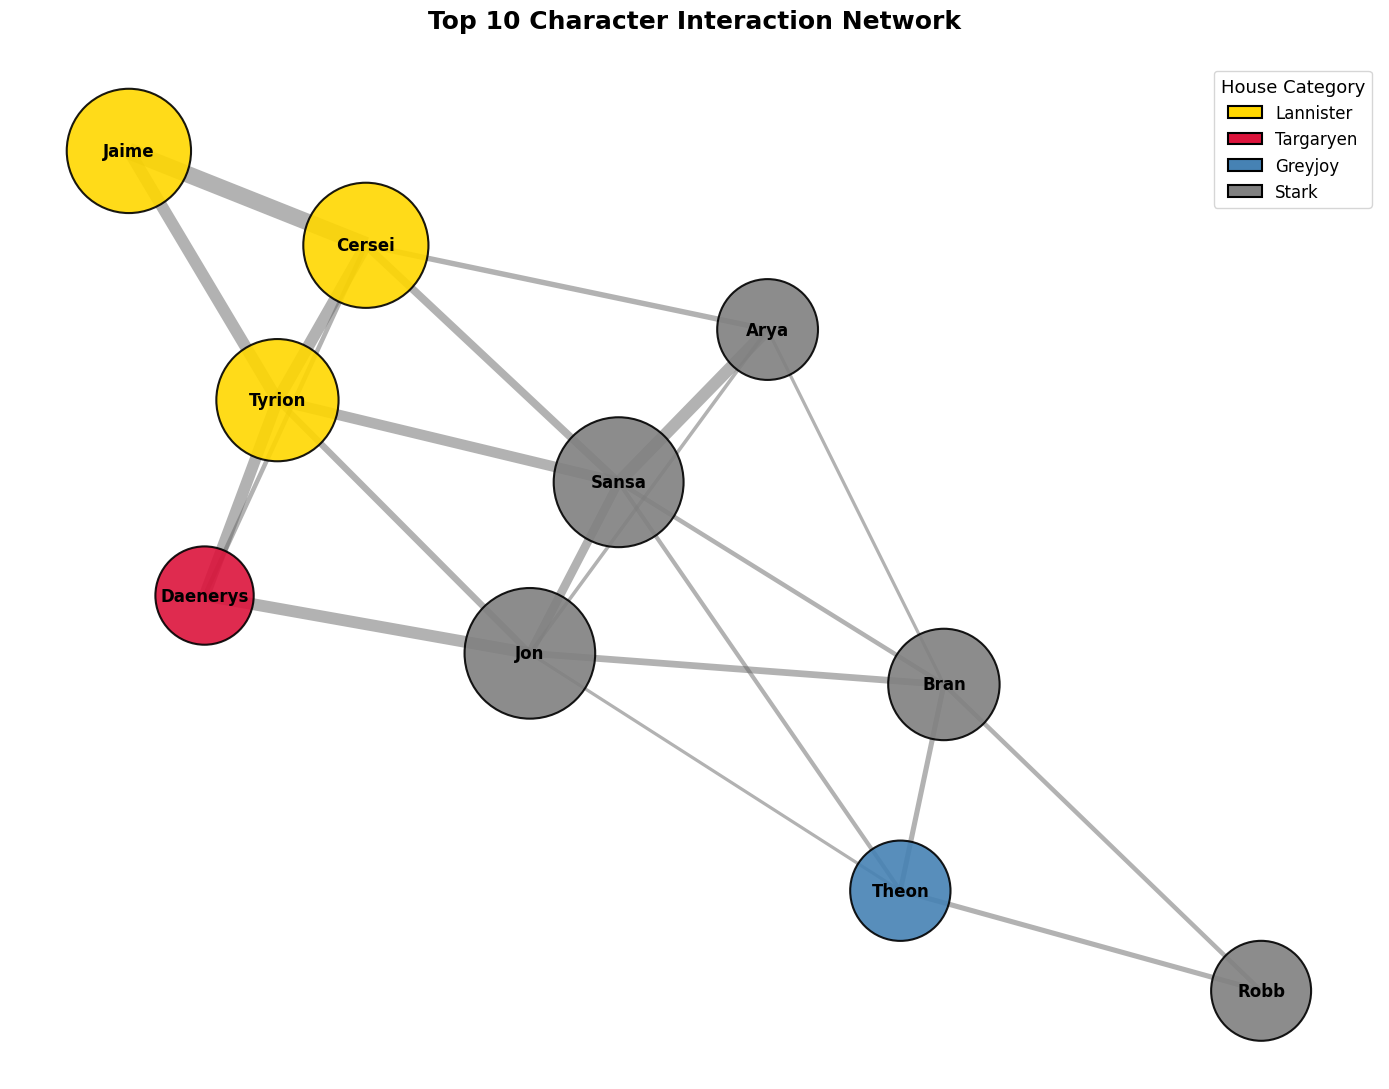

In [10]:
# weighted Dialogue Network
from matplotlib.patches import Patch

# define house colors
house_colors_map = {
    'Stark': '#808080',          # grey
    'Lannister': '#FFD700',      # yellow
    'Targaryen': '#DC143C',      # red
    'Greyjoy': '#4682B4',        # blue
}

fig, ax = plt.subplots(figsize=(14, 11))

# create undirected graph for visualization
G_viz = nx.Graph()
for speaker, targets in interactions.items():
    for target, weight in targets.items():
        if G_viz.has_edge(speaker, target):
            G_viz[speaker][target]['weight'] += weight
        else:
            G_viz.add_edge(speaker, target, weight=weight)

# filter for Top 10 characters based on PageRank
char_to_pagerank = char_features.set_index('Character')['network_pagerank'].to_dict()
top_10_chars = sorted(G_viz.nodes(), key=lambda x: char_to_pagerank.get(x, 0), reverse=True)[:10]
G_10 = G_viz.subgraph(top_10_chars).copy()

# filter weak edges (keep only top 50% of interactions)
edges_with_weights = [(u, v, d['weight']) for u, v, d in G_10.edges(data=True)]
if edges_with_weights:
    weights_list = [w for u, v, w in edges_with_weights]
    weight_threshold = np.percentile(weights_list, 50)  # keep edges above median weight

    # remove weak edges
    edges_to_remove = [(u, v) for u, v, w in edges_with_weights if w < weight_threshold]
    G_10.remove_edges_from(edges_to_remove)
    # print(f"Edge filtering: Kept {G_10.number_of_edges()} strong edges (threshold: {weight_threshold:.1f} interactions)")

# optimized layout for 10 nodes to prevent overlapping labels
pos = nx.spring_layout(G_10,
                       k=3.0,
                       iterations=100,
                       seed=42,
                       weight='weight')

# prepare node attributes
char_to_house = char_features.set_index('Character')['House'].to_dict()
char_to_house_category = char_features.set_index('Character')['House_Category'].to_dict()
node_colors = [house_colors_map.get(char_to_house_category.get(node, 'Other Notable'), '#CCCCCC')
               for node in G_10.nodes()]
node_sizes = [char_to_pagerank.get(node, 0.01) * 100000 for node in G_10.nodes()]

# draw edges
edges = G_10.edges()
if len(edges) > 0:
    weights = np.array([G_10[u][v]['weight'] for u, v in edges])
    edge_widths = (weights / weights.max()) * 12
else:
    edge_widths = 1

nx.draw_networkx_edges(G_10, pos, width=edge_widths, alpha=0.5, edge_color='#666666', ax=ax)

# draw nodes
nx.draw_networkx_nodes(G_10, pos, node_color=node_colors, node_size=node_sizes,
                       alpha=0.9, edgecolors='black', linewidths=1.5, ax=ax)

# draw labels
nx.draw_networkx_labels(G_10, pos, font_size=12, font_family='sans-serif', font_weight='bold', ax=ax)

ax.set_title('Top 10 Character Interaction Network',
             fontsize=18, fontweight='bold', pad=25)
ax.axis('off')

# dynamic legend based on house categories
current_house_categories = set([char_to_house_category.get(node) for node in G_10.nodes()])
legend_elements = [Patch(facecolor=house_colors_map.get(cat, '#CCCCCC'), label=cat, edgecolor='black', linewidth=1.5)
                   for cat in current_house_categories if cat in house_colors_map]

ax.legend(handles=legend_elements, loc='upper right', fontsize=12,
          title='House Category', title_fontsize=13, frameon=True)

plt.tight_layout()
plt.show()

**Key Findings:**
- Jon has the largest node size, representing the highest PageRank. This indicates that he is not only talkative but is connected to other highly influential characters (Sansa also shows a similar pattern)




## The Reputation Matrix

Using the hierarchical interaction model, I create a weighted reputation matrix showing how different Houses address specific characters. This heatmap will show how characters are addressed by different Houses, revealing each character's "social fingerprint."
- **Positive scores**: Character is addressed with positive sentiment (beloved/respected)  
- **Negative scores**: Character is addressed with negative sentiment (feared/disliked)  
- **Pattern variance**: High variance indicates polarized political standing

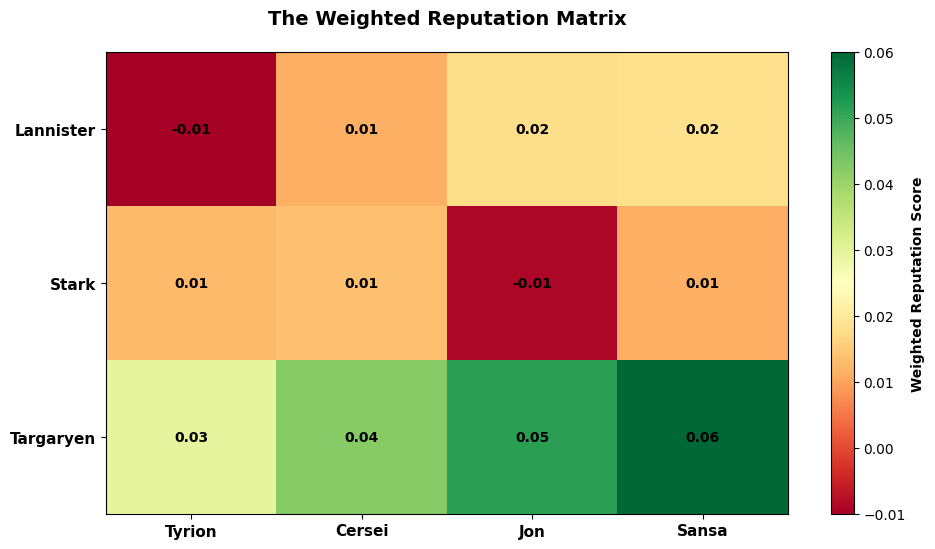

In [11]:
# define scenes by grouping consecutive dialogue by Season and Episode
scenes = []
for (season, episode), group in df_major.groupby(['Season', 'Episode']):
    scenes.append(group.index.tolist())

# I assign different weights to interactions based on how directly the speaker is addressing the target character:
# - Direct name mentions in dialogue get the highest weight (80%) as they indicate a clear interaction.
# - Speakers within a +/- 3 turn window get a moderate weight (30%) as they are likely part of the same conversational flow and may be influencing each other.
# - Everyone else in the scene gets a lower weight (10%) as they provide ambient context but may not be directly interacting with the speaker.
WEIGHT_DIRECT = 0.80
WEIGHT_WINDOW = 0.30
WEIGHT_GROUP  = 0.10

reputation_data = []

# process each scene to identify interactions
for scene_indices in scenes:
    # get the data for just this scene
    scene_df = df_major.loc[scene_indices]
    scene_chars = scene_df['Character'].unique().tolist()

    # iterate through each dialogue line in the scene
    # .reset_index(drop=True) allows me to use relative 'i' for turn windows
    scene_df_reset = scene_df.reset_index()
    for i, row in scene_df_reset.iterrows():
        speaker = row['Character']
        speaker_house = row['House']
        dialogue = str(row['Sentence']).lower()
        sentiment = row['sentiment_compound']

        # 1. direct addressing (80% Weight)
        for target_char in top_20_characters:
            if target_char != speaker:
                if re.search(r'\b' + re.escape(target_char.lower()) + r'\b', dialogue):
                    reputation_data.append({
                        'speaker_house': speaker_house,
                        'target_character': target_char,
                        'weighted_sentiment': sentiment * WEIGHT_DIRECT,
                        'interaction_weight': WEIGHT_DIRECT
                    })

        # 2. turn window (30% Weight)
        # look at speakers 3 lines before and 3 lines after
        start_idx = max(0, i - 3)
        end_idx = min(len(scene_df_reset), i + 4)
        window_chars = scene_df_reset.iloc[start_idx:end_idx]['Character'].unique().tolist()

        for target_char in window_chars:
            if target_char != speaker:
                reputation_data.append({
                    'speaker_house': speaker_house,
                    'target_character': target_char,
                    'weighted_sentiment': sentiment * WEIGHT_WINDOW,
                    'interaction_weight': WEIGHT_WINDOW
                })

        # 3. group context (10% Weight)
        # every other character present in the scene
        for target_char in scene_chars:
            if target_char != speaker:
                reputation_data.append({
                    'speaker_house': speaker_house,
                    'target_character': target_char,
                    'weighted_sentiment': sentiment * WEIGHT_GROUP,
                    'interaction_weight': WEIGHT_GROUP
                })

# convert to DataFrame
reputation_df = pd.DataFrame(reputation_data)

# calculate Weighted Averages
agg_reputation = reputation_df.groupby(['speaker_house', 'target_character']).agg({
    'weighted_sentiment': 'sum',
    'interaction_weight': 'sum'
}).reset_index()

agg_reputation['final_score'] = agg_reputation['weighted_sentiment'] / agg_reputation['interaction_weight']

# pivot to create matrix format
matrix_pivot = agg_reputation.pivot(index='speaker_house', columns='target_character', values='final_score')

# filtering Logic (Top 3 Houses and top 4 characters)
top_chars = reputation_df['target_character'].value_counts().head(4).index
top_houses = reputation_df['speaker_house'].value_counts().head(3).index
matrix_pivot_filtered = matrix_pivot.loc[top_houses, top_chars].fillna(0)

# heatmap Visualization
fig, ax = plt.subplots(figsize=(11, 6))
im = ax.imshow(matrix_pivot_filtered.values, cmap='RdYlGn', aspect='auto', vmin=-0.01, vmax=0.06)

# formatting
ax.set_xticks(np.arange(len(matrix_pivot_filtered.columns)))
ax.set_yticks(np.arange(len(matrix_pivot_filtered.index)))
ax.set_xticklabels(matrix_pivot_filtered.columns, fontsize=11, fontweight='bold')
ax.set_yticklabels(matrix_pivot_filtered.index, fontsize=11, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=0, ha="center")

# add colorbar and text
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Weighted Reputation Score', fontweight='bold')

# add text annotations to each cell
for i in range(len(matrix_pivot_filtered.index)):
    for j in range(len(matrix_pivot_filtered.columns)):
        val = matrix_pivot_filtered.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha="center", va="center", fontweight='bold')

ax.set_title('The Weighted Reputation Matrix', fontsize=14, fontweight='bold', pad=20)
plt.show()

**Key Findings:**
- Tyrion Lannister has a negative reputation (-0.01) when associated with his own house, Lannister. Despite his brilliance, the Lannister family (specifically Tywin and Cersei) viewed him as a "shameful" outlier due to his dwarfism.
- Jon's reputation is highly polarized. He has one of the lowest scores (under Stark) and one of the highest (0.05 under Targaryen). Under the Stark name, Jon is historically "The Bastard of Winterfell." In a feudal society, being a bastard carries a reputation penalty.
- Regardless of the character, being associated with House Targaryen yields the highest reputation scores in this dataset.
- Lannister & Stark: These houses hover in the "low-to-mid" range (mostly 0.01 to 0.02). They seem to struggle to generate high reputation scores for these specific characters compared to the Targaryen affiliation.



## Modeling: Does PageRank Predict Reputation?

Having explored social fingerprints through descriptive analysis, I now test whether network centrality (PageRank) statistically predicts a character's reputation. I fit a simple linear regression model to quantify this relationship.


,network_pagerank,reputation_sentiment,sentiment_compound
0,0.053,-0.011,-0.036
1,0.064,-0.022,0.007
2,0.034,0.029,0.015
3,0.081,-0.006,0.019
4,0.050,-0.005,0.038


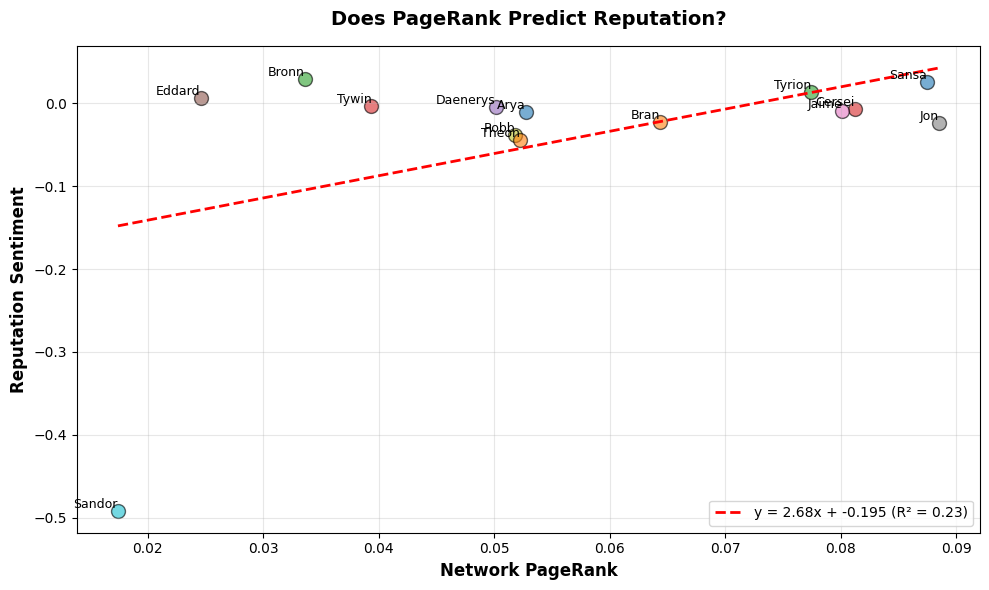

In [12]:
# prepare data for modeling
from scipy import stats

# filter to characters with both pagerank and reputation data
model_data = char_features[char_features['reputation_sentiment'] != 0].copy()

display(model_data[['network_pagerank', 'reputation_sentiment', 'sentiment_compound']].head().round(3))

# fit simple linear regression: reputation ~ PageRank
X = model_data['network_pagerank'].values
y = model_data['reputation_sentiment'].values

# calculate regression coefficients
slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

# visualize the relationship
fig, ax = plt.subplots(figsize=(10, 6))

# scatter plot with character labels
for idx, row in model_data.iterrows():
    ax.scatter(row['network_pagerank'], row['reputation_sentiment'],
               s=100, alpha=0.6, edgecolors='black', linewidth=1)
    ax.text(row['network_pagerank'], row['reputation_sentiment'],
            row['Character'], fontsize=9, ha='right', va='bottom')

# regression line
x_line = np.linspace(X.min(), X.max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r--', linewidth=2, label=f'y = {slope:.2f}x + {intercept:.3f} (R² = {r_value**2:.2f})')

ax.set_xlabel('Network PageRank', fontsize=12, fontweight='bold')
ax.set_ylabel('Reputation Sentiment', fontsize=12, fontweight='bold')
ax.set_title('Does PageRank Predict Reputation?', fontsize=14, fontweight='bold', pad=15)
ax.legend(loc='best', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Note:**
- The character Sandor has a very low PageRank and low reputaion sentiments (near 0.5).
- The R^2 value is 0.23, meaning PageRank only explains 23% of the variation in a character’s reputation, while 77% is influenced by other factors not captured in the network. This means charaters who talk more are liked more when in reality the pattern is much more complex


## Conclusion

This computational linguistic analysis revealed some kinds of "social fingerprints" for Game of Thrones characters through dialogue patterns.

### Key Findings

**1. House-Specific Communication**

House Targaryen utilizes assertive, positive rhetoric focused on justice and legitimacy. In contrast, House Stark prioritizes neutral, duty-bound speech, while House Greyjoy is defined by a confrontational and negative communication style.

**2. Power Dynamics and Networks**

Influence is unevenly distributed across the social landscape. Jon Snow serves as a primary conversational hub, connecting disparate factions. While Houses Targaryen and Lannister dominate through command-based language, most power is negotiated through formal, one-on-one interactions rather than public declarations.

**3. Reputation Polarization**

A character's reputation is heavily dependent on their current House association:

- **Jon Snow**: His perception is bifurcated, shifting from a lower status under the Stark name to a highly prestigious one under the Targaryen banner.
- **Tyrion Lannister**: He faces internal house friction, receiving negative sentiment from the Lannisters despite his strategic value.
- **The Targaryen Advantage**: Affiliation with House Targaryen consistently yields the highest reputation scores, suggesting their "liberation" narrative is more effective than the pragmatism of other houses.

### Limitations

This analysis acknowledges several constraints:

- **Regex keyword matching cannot distinguish context** (e.g., "the north" as direction vs. political entity)

- **Text-only analysis misses vocal tone**, potentially overlooking sarcasm or ironic speech (e.g., Varys's emphasis: "Your Grace, Lady Sansa **IS** your aunt by marriage" vs. neutral "Your Grace, Lady Sansa is your aunt by marriage" indicates emphasis/sarcasm that sentiment analysis cannot detect)

- **Hierarchical weighting model** (80% direct, 30% turn-window, 10% ambient) may oversimplify conversational dynamics

- **Exclusion of minor houses and generic characters** (44.4% of data) limits understanding of broader social context

- **Domain knowledge required**: The approach requires extensive prior knowledge of Game of Thrones universe, making it not generalizable to new datasets without external knowledge or labeled training data:

  - Must manually identify major houses (I selected 6: Stark, Lannister, Targaryen, Baratheon, Greyjoy, Tyrell)

  - Must know house-specific locations, mottos, and titles to construct regex patterns

  - Must manually assign character-to-house allegiances (e.g., knowing "Tyrion" is Lannister, "Ned" is Stark)

- **Sample size imbalance**: Characters with minimal dialogue are harder to analyze accurately, while some houses have very few representative characters in the dataset

- **Temporal dynamics ignored**: Characters who change allegiances over time (e.g., Theon's capture by Boltons, Jaime's redemption arc) present classification challenges that static house assignments cannot capture

### Modeling

This analysis includes a simple linear regression model testing whether network centrality (PageRank) statistically predicts a character's reputation. I fit a simple linear regression model to quantify this relationship.. Future implementations could extend this approach with:

- **Outlier removal** (e.g., Sandor) to prevent extreme data points from skewing the R^2 and creating misleading trend lines
- **Multiple regression** to control for confounding variables such as house affiliation, screen time, and character role
- **Time-series analysis** to track how character communication styles and reputations evolve across different seasons
- **Interaction effects** to test whether power language has different reputational effects depending on the specific house context

### Final Reflection

The data suggests a strong correlation between House address and social status; however, the 'social fingerprint' remains an incomplete picture. While we can see broad reputation shifts (like Jon Snow's), I think my current analysis cannot yet account for the sarcasm, irony, or shifting allegiances that define the true complexity of Westeros politics.